# Assignment 2

Explore global CO₂ and greenhouse gas data using Python.\
Dataset: `CO2_Emissions_Sample`

In [1]:
import numpy as np
import pandas as pd
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns

## Preprocessing

### Import

In [2]:
# df = pd.read_csv('../assets/CO2_Emissions_Sample.csv')
df = pd.read_csv('https://raw.githubusercontent.com/TheChroniclerr/CP321/refs/heads/main/a2/assets/CO2_Emissions_Sample.csv')

In [3]:
df.head()

,Country,Continent,Year,CO2_Emissions,Methane_Emissions,Nitrous_Emissions,GDP,Population
0,Canada,North America,2000,7750.862683,1053.030592,371.225407,734.472170,3.510898e+07
1,Canada,North America,2001,7955.423607,1023.118633,199.876401,17204.341086,7.396990e+07
2,Canada,North America,2002,8690.632912,994.091186,459.825424,37012.640134,1.296462e+07
3,Canada,North America,2003,NaN,489.361214,460.923247,29251.111335,2.075688e+07
4,Canada,North America,2004,7324.463432,1077.207390,408.154588,23575.082668,1.239332e+07


### Clean

In [4]:
# Display infos
print(df.isna().sum())
print('------')
print(df.dtypes)

Country               0
Continent             0
Year                  0
CO2_Emissions        20
Methane_Emissions    20
Nitrous_Emissions     0
GDP                  20
Population            0
dtype: int64
------
Country               object
Continent             object
Year                   int64
CO2_Emissions        float64
Methane_Emissions    float64
Nitrous_Emissions    float64
GDP                  float64
Population           float64
dtype: object


In [5]:
# Mean imputate
df[['CO2_Emissions', 'Methane_Emissions', 'GDP']] = (
    df[['CO2_Emissions', 'Methane_Emissions', 'GDP']].fillna(df[['CO2_Emissions', 'Methane_Emissions', 'GDP']].mean())
)
print(df.isna().sum())

# Lock a cleaned copy for export
df_cleaned = df.copy()

Country              0
Continent            0
Year                 0
CO2_Emissions        0
Methane_Emissions    0
Nitrous_Emissions    0
GDP                  0
Population           0
dtype: int64


## Part A – Visualizing Amounts

### Bar Chart

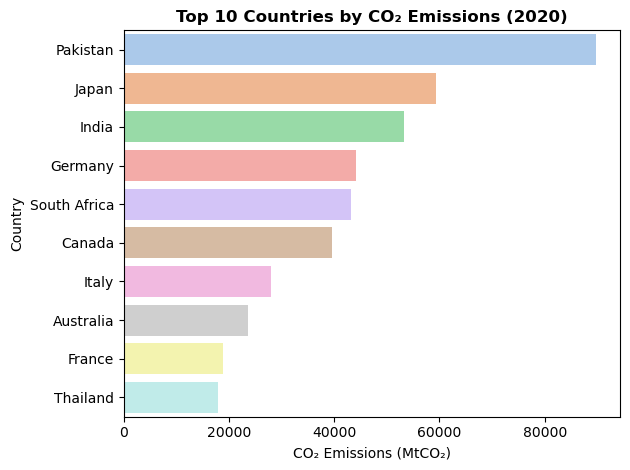

In [6]:
df_2020 = df[df['Year'] == 2020]
top10_2020 = df_2020.sort_values('CO2_Emissions', ascending=False).head(10)

plt.figure()
sns.barplot(
    data=top10_2020,
    orient='h',
    x='CO2_Emissions',
    y='Country',
    hue='Country', 
    palette='pastel'
)

plt.title("Top 10 Countries by CO₂ Emissions (2020)", fontsize=12, fontweight='bold')
plt.xlabel("CO₂ Emissions (MtCO₂)")
plt.ylabel("Country")
# plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

### Stacked Bar Chart

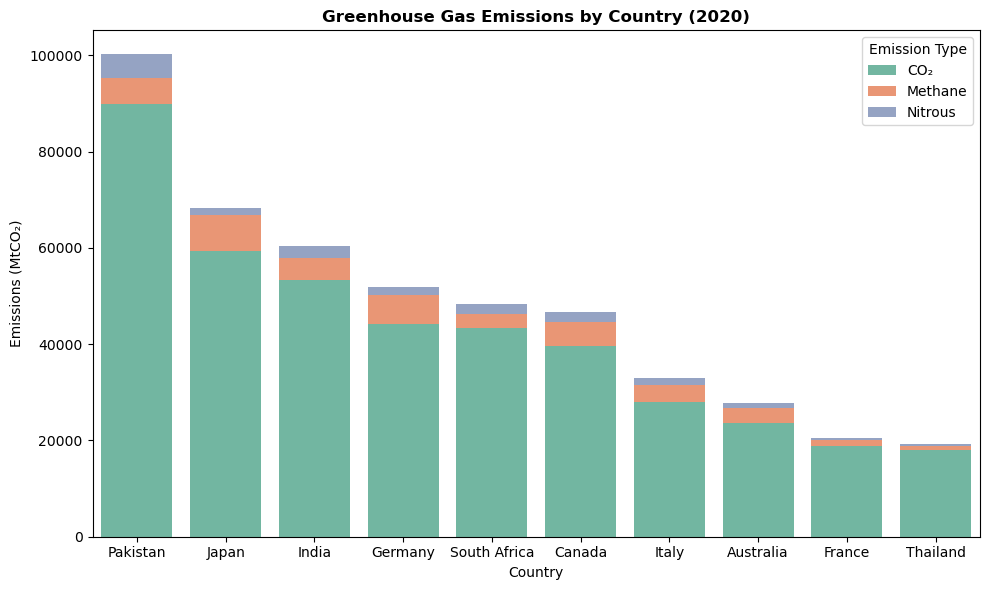

In [7]:
df_long = top10_2020.melt(  # Melt the gas columns into long-form
    id_vars="Country",
    value_vars=["CO2_Emissions", "Methane_Emissions", "Nitrous_Emissions"],
    var_name="Gas",
    value_name="Emissions"
)

df_long["Gas"] = df_long["Gas"].replace({   # Rename for cleaner legend
    "CO2_Emissions": "CO₂",
    "Methane_Emissions": "Methane",
    "Nitrous_Emissions": "Nitrous"
})

plt.figure(figsize=(10,6))

bottoms = np.zeros(len(top10_2020))         # Initialize bottom array
for gas in ["CO₂", "Methane", "Nitrous"]:   # Plot each gas type in order
    sns.barplot(
        data=df_long[df_long["Gas"] == gas],
        x="Country",
        y="Emissions",
        bottom=bottoms,  # cumulative bottom
        label=gas,
        color=sns.color_palette("Set2")[["CO₂","Methane","Nitrous"].index(gas)]
    )

    bottoms += df_long[df_long["Gas"] == gas]["Emissions"].to_numpy()   # Update bottoms for next gas

plt.ylabel("Emissions (MtCO₂)")
plt.xlabel("Country")
plt.title("Greenhouse Gas Emissions by Country (2020)", fontsize=12, fontweight='bold')
plt.legend(title="Emission Type")
# plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## Part B – Visualizing Associations

### Scatter Plot

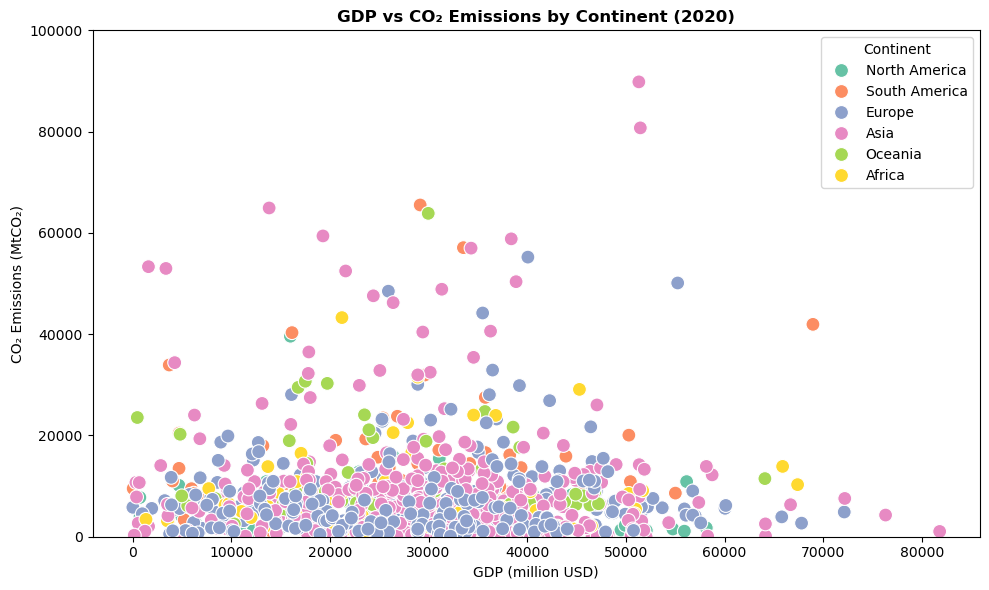

In [8]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='GDP',
    y='CO2_Emissions',
    hue='Continent',
    palette='Set2',
    s=100   # marker size
)

plt.title("GDP vs CO₂ Emissions by Continent (2020)", fontsize=12, fontweight='bold')
plt.xlabel("GDP (million USD)")
plt.ylabel("CO₂ Emissions (MtCO₂)")
# plt.legend(title="Continent", bbox_to_anchor=(1.05, 1), loc='upper left')   # move legend outside the plot

plt.ylim(0, 100000)     # cutoff outliers with >400000
plt.tight_layout()
plt.show()

### Bubble Chart

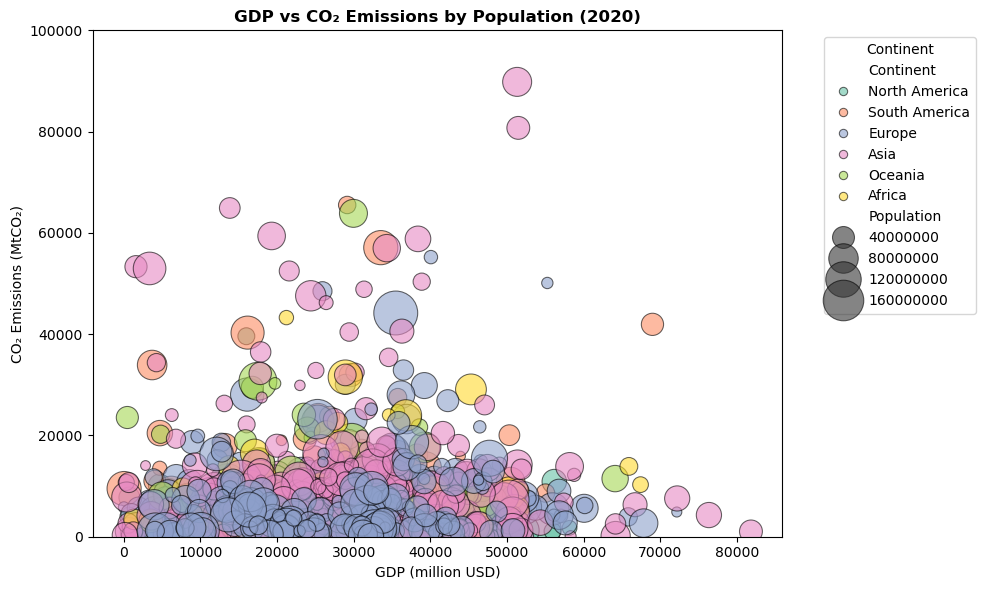

In [9]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x='GDP',
    y='CO2_Emissions',
    size='Population',
    hue='Continent',
    palette='Set2',
    sizes=(50, 1000),       # min and max bubble size
    alpha=0.6,              # bubbles transparency
    edgecolor="black"       # bubbles border color
)

plt.title("GDP vs CO₂ Emissions by Population (2020)", fontsize=12, fontweight='bold')
plt.xlabel("GDP (million USD)")
plt.ylabel("CO₂ Emissions (MtCO₂)")
plt.legend(title="Continent", bbox_to_anchor=(1.05, 1), loc='upper left')   # move legend outside the plot

plt.ylim(0, 100000)     # cutoff outliers with >400000
plt.tight_layout()
plt.show()

### Correlogram

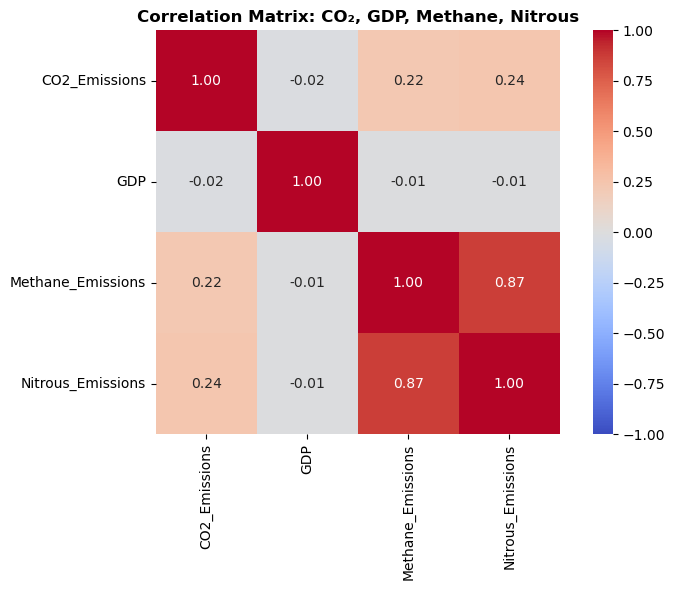

In [10]:
df_corr = df[["CO2_Emissions", "GDP", "Methane_Emissions", "Nitrous_Emissions"]].corr()   # compute correlation

plt.figure(figsize=(8,6))
sns.heatmap(
    data=df_corr, 
    annot=True,       # show correlation values
    fmt=".2f",        # 2 decimal places
    square=True,      # make cells square
    cmap="coolwarm",  # diverging color map: blue-negative, red-positive
    vmin=-1, vmax=1   # set color scale range
)

plt.title("Correlation Matrix: CO₂, GDP, Methane, Nitrous", fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

### Analysis
**Outliers**
- Most emmision fall <100000, except for 5 outliers >400000.
    - Removed to avoid squashing of the majority dataset.

**Scatter Plot**
- The plot does not indicate a strong correlation between GDP and emission due to the large spread.
- The scatter plot's legend is ineffective due to large overlaps; however, it is suffient for showing the correlation.

**Bubble Chart**
- Again, this plot does not indicate a strong correlation.
- The bubble chart legend is better than scatter plot, but it still does not resolve the overlaps and cluttering.

**Correlation Matrix**
- There is a strong positive correlation between methane and nitrous emissions, indicating that they tend to rise and fall together.
- There is a weak positive correlation between CO₂ and nitrous/methane emissions.
- Correlation matrix is useful for indicating the correlation between each variable.

## Part C – Visualizing Proportions

### Stacked Bar Chart (Relative)

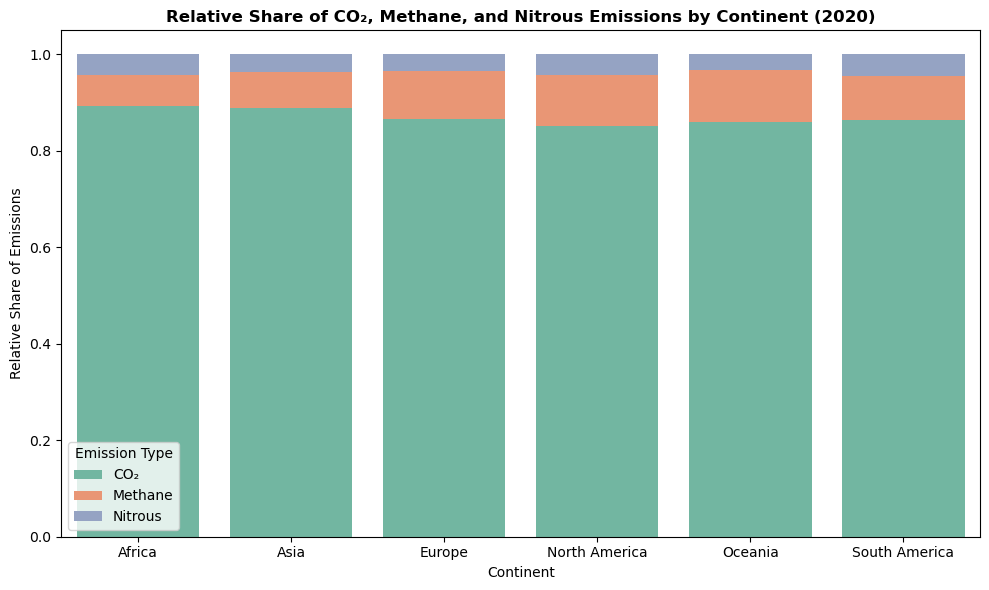

In [11]:
continent_emissions = df_2020.groupby("Continent")[["CO2_Emissions", "Methane_Emissions", "Nitrous_Emissions"]].sum()   # Aggregate emissions by continent
continent_emissions_pct = continent_emissions.div(continent_emissions.sum(axis=1), axis=0)  # Compute relative share (fraction of total emissions per continent)

df_long = continent_emissions_pct.reset_index().melt(   # Melt into long-form
    id_vars="Continent",
    value_vars=["CO2_Emissions", "Methane_Emissions", "Nitrous_Emissions"],
    var_name="Gas",
    value_name="Emissions"
)

df_long["Gas"] = df_long["Gas"].replace({   # Rename variables
    "CO2_Emissions": "CO₂",
    "Methane_Emissions": "Methane",
    "Nitrous_Emissions": "Nitrous"
})

plt.figure(figsize=(10,6))

bottoms = np.zeros(len(continent_emissions_pct))
for gas in ["CO₂", "Methane", "Nitrous"]:
    sns.barplot(
        data=df_long[df_long["Gas"] == gas],
        x="Continent",
        y="Emissions",
        bottom=bottoms,
        label=gas,
        color=sns.color_palette("Set2")[["CO₂","Methane","Nitrous"].index(gas)]
    )
    
    bottoms += df_long[df_long["Gas"] == gas]["Emissions"].to_numpy()   # Update cumulative bottoms

plt.ylabel("Relative Share of Emissions")
plt.xlabel("Continent")
plt.title("Relative Share of CO₂, Methane, and Nitrous Emissions by Continent (2020)", fontsize=12, fontweight='bold')
plt.legend(title="Emission Type")

plt.tight_layout()
plt.show()

### Pie Chart

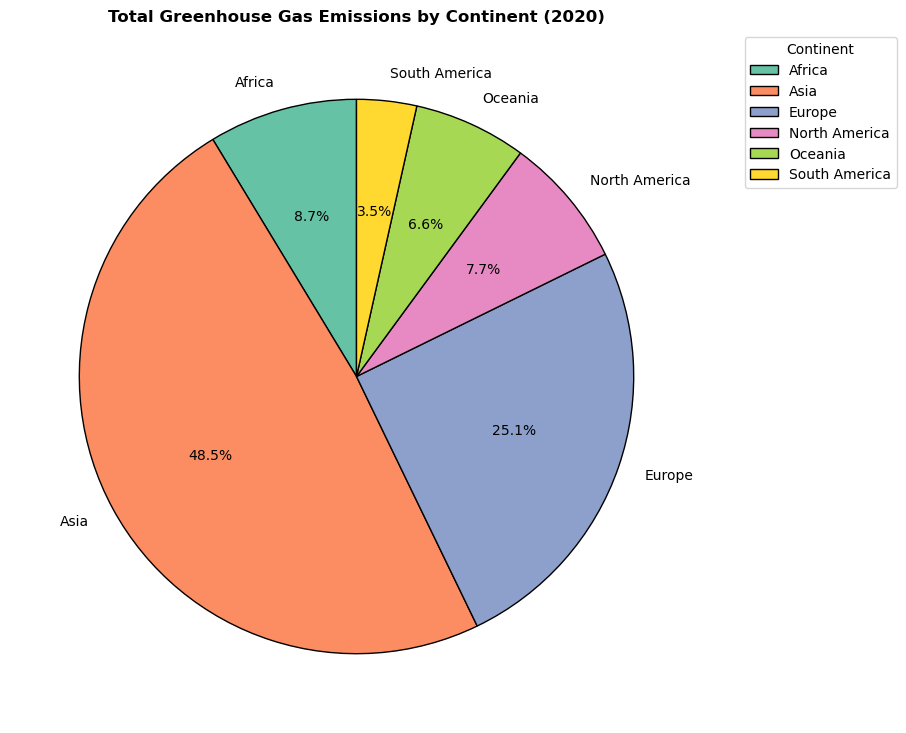

In [12]:
df_2020_cpy = df_2020.copy()
df_2020_cpy["Total_Emissions"] = df_2020[["CO2_Emissions", "Methane_Emissions", "Nitrous_Emissions"]].sum(axis=1)
region_emissions = df_2020_cpy.groupby("Continent")["Total_Emissions"].sum()

plt.figure(figsize=(9,9))
plt.pie(
    region_emissions,
    labels=list(region_emissions.index),
    autopct="%1.1f%%",      # show percentages
    startangle=90,          # rotate first slice
    colors=sns.color_palette("Set2", len(region_emissions)),
    wedgeprops={"edgecolor": "black"}
)

plt.legend(
    labels=list(region_emissions.index),  # convert Index to list
    title="Continent",
    bbox_to_anchor=(1.05, 1),             # move outside plot
    loc="upper left"
)

plt.title("Total Greenhouse Gas Emissions by Continent (2020)", fontsize=12, fontweight='bold')
plt.show()

## Part D – Visualizing Time Series

### Line Chart

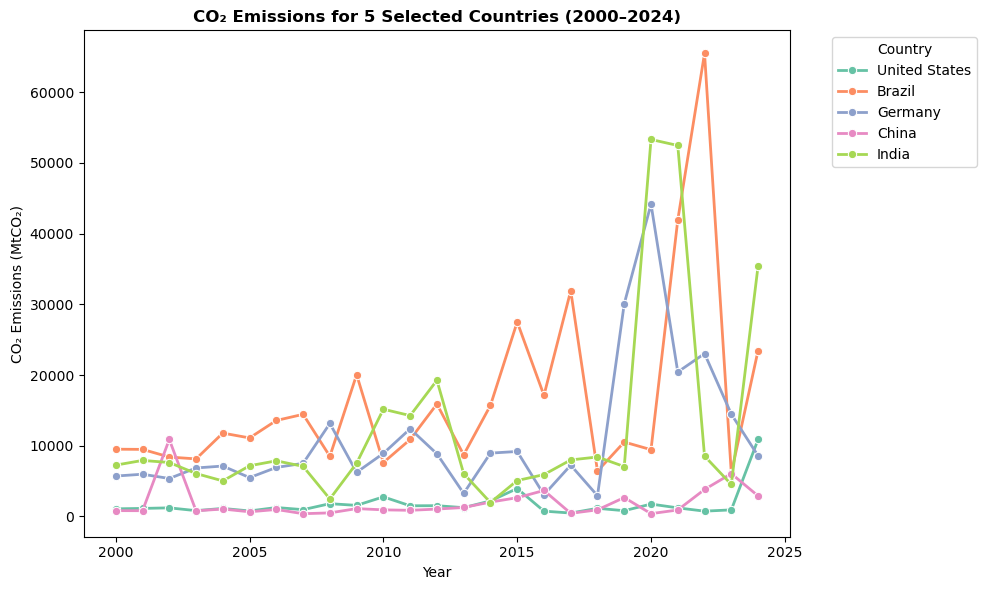

In [13]:
selected_countries = ["United States", "China", "India", "Germany", "Brazil"]   # Selected countries
df_selected = df[df["Country"].isin(selected_countries)]

plt.figure(figsize=(10,6))
sns.lineplot(
    data=df_selected,
    x="Year",
    y="CO2_Emissions",
    marker="o",       # markers at each year
    palette="Set2",
    hue="Country",
    linewidth=2
)

plt.title("CO₂ Emissions for 5 Selected Countries (2000–2024)", fontsize=12, fontweight='bold')
plt.ylabel("CO₂ Emissions (MtCO₂)")
plt.xlabel("Year")
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Line Chart (Smoothed)

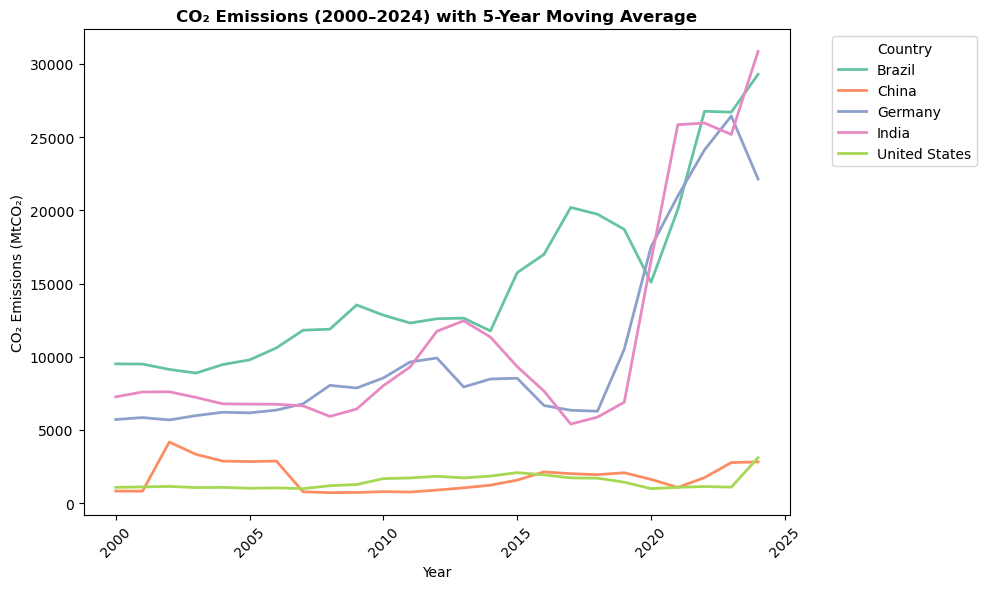

In [14]:
df_smoothed = df_selected.sort_values(["Country", "Year"])
df_smoothed["CO2_MA5"] = df_smoothed.groupby("Country")["CO2_Emissions"].transform(lambda x: x.rolling(5, min_periods=1).mean())

plt.figure(figsize=(10,6))

# sns.lineplot(   # Original lines
#     data=df_smoothed,
#     x="Year",
#     y="CO2_Emissions",
#     marker="o",
#     palette="Set2",
#     hue="Country",
#     alpha=0.4,   # lighter so MA stands out
#     linewidth=1
# )

sns.lineplot(   # Smoothed lines
    data=df_smoothed,
    x="Year",
    y="CO2_MA5",
    hue="Country",
    palette="Set2",
    linewidth=2
)

plt.ylabel("CO₂ Emissions (MtCO₂)")
plt.xlabel("Year")
plt.title("CO₂ Emissions (2000–2024) with 5-Year Moving Average", fontsize=12, fontweight='bold')
plt.xticks(rotation=45)
plt.legend(title="Country", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Analysis
**Observation**
- The first chart is lot spikier than the second smoothed out chart.
    - The first chart shows more detailed trends per year.
    - The second chart shows more general long term trends.

**Discussion**
- The **first chart** indicates emission usually spike in certain years instead of being consistently higher, and then lowers back down.
- The **second chart** indicates an increase in emission for developing countries whereas for developed countries its stable/flat.
- Overall, **both charts** indicate developing country in general has much higher emission than developed country.
    - The spikes potentially indicate period of industrialization and development, leading to high emissions.
    - Germany is an exception for it is considered a "developed country". It is still obvious, however, that known developing countries such as Brazil and India shows much higher emissions.

## Part E – PCA Representation

### 1) Data aggregation

In [15]:
# a)
print(df_2020.head())

# b)
continent_features = (
    df_2020.groupby('Continent')[[
        "CO2_Emissions",
        "Methane_Emissions",
        "Nitrous_Emissions",
        "GDP",
        "Population"
    ]].mean()
)
print('------')
print(continent_features)

           Country      Continent  Year  CO2_Emissions  Methane_Emissions  \
20          Canada  North America  2020   39594.595515        5063.162481   
45   United States  North America  2020    1751.506594         160.983479   
70          Mexico  North America  2020     324.689166          19.082275   
95          Brazil  South America  2020    9447.267733        1084.497666   
120      Argentina  South America  2020    7266.118286         719.127539   

     Nitrous_Emissions           GDP    Population  
20         1927.290993  15995.734800  1.972812e+07  
45          102.724595  58152.669169  1.266217e+07  
70           15.037827  42698.759788  1.452817e+06  
95          435.493745  39287.566755  1.303708e+07  
120         431.764424  33624.895797  5.874810e+07  
------
               CO2_Emissions  Methane_Emissions  Nitrous_Emissions  \
Continent                                                            
Africa          16512.669572        1195.076421         783.345290   
As

### 2) PCA feature extraction

In [16]:
# a)
scaler = sklearn.preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(continent_features)

# b)
pca = sklearn.decomposition.PCA()
X_pca = pca.fit_transform(X_scaled)

# c)
explained_variance = pca.explained_variance_ratio_ * 100
print(f"PC1 explains {explained_variance[0]:.2f}% of the variance")
print(f"PC2 explains {explained_variance[1]:.2f}% of the variance")

PC1 explains 55.01% of the variance
PC2 explains 36.02% of the variance


### 3)  Visualization

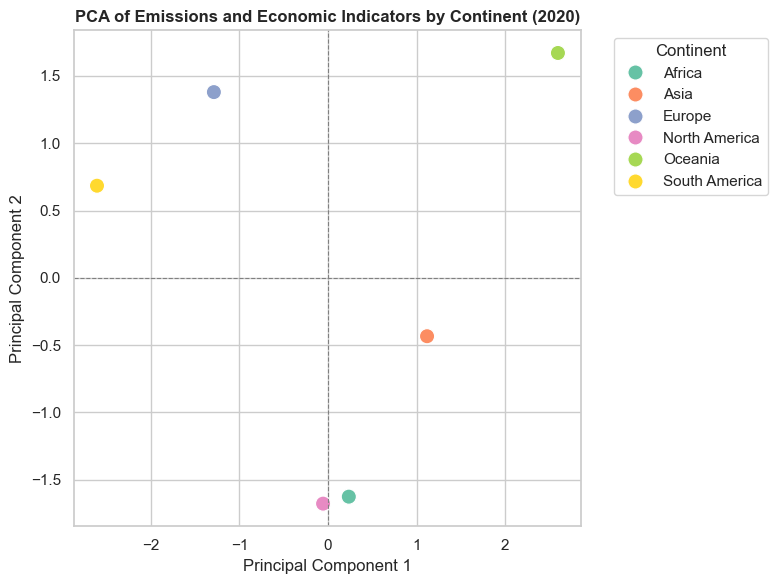

In [17]:
pca_df = continent_features.reset_index()
pca_df["PC1"] = X_pca[:, 0]
pca_df["PC2"] = X_pca[:, 1]

sns.set_theme(style="whitegrid")
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Continent",
    palette="Set2",
    s=120
)

plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)

plt.title("PCA of Emissions and Economic Indicators by Continent (2020)", fontsize=12, fontweight="bold")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Continent", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

### 4) Interpretation
**a)**
PCA is appropriate after aggregating by continent because the dataset contains multiple correlated variables (CO₂, Methane, Nitrous emissions, GDP, and Population). Aggregation reduces noise at the country level and allows PCA to highlight broad structural differences between continents.

Principal Component 1 (PC1) captures the dominant pattern of variation across continents, which is largely driven by overall scale of emissions and economic size. Principal Component 2 (PC2) captures secondary variation, reflecting differences in emissions composition and economic–population balance that are not explained by PC1.

**b)**
Continents that appear close together in the PCA plot have similar emissions and economic profiles, while those farther apart differ substantially. Continents with high emissions and large economies tend to score strongly on PC1, while continents with lower emissions and smaller economies appear on the opposite side. Separation along PC2 suggests differences in relative contributions of greenhouse gases or population-adjusted economic characteristics.

## Part F – Completeness and Design
✅ Ensure clear legends, color scales, titles, and captions. 

✅ Apply the principle of proportional ink. 

✅ Avoid clutter and overplotting
### Export

In [18]:
# Export cleaned CSV
df_cleaned.to_csv("../outputs/cleaned.csv", index=False)
df_cleaned

,Country,Continent,Year,CO2_Emissions,Methane_Emissions,Nitrous_Emissions,GDP,Population
0,Canada,North America,2000,7750.862683,1053.030592,371.225407,734.472170,3.510898e+07
1,Canada,North America,2001,7955.423607,1023.118633,199.876401,17204.341086,7.396990e+07
2,Canada,North America,2002,8690.632912,994.091186,459.825424,37012.640134,1.296462e+07
3,Canada,North America,2003,10886.951636,489.361214,460.923247,29251.111335,2.075688e+07
4,Canada,North America,2004,7324.463432,1077.207390,408.154588,23575.082668,1.239332e+07
...,...,...,...,...,...,...,...,...
995,Denmark,Europe,2020,1508.896064,137.853218,77.492468,23858.016712,2.546186e+07
996,Denmark,Europe,2021,1768.923688,161.366640,89.073391,8797.371026,7.945323e+07
997,Denmark,Europe,2022,106.853195,11.279579,5.083564,32222.683168,5.808309e+07
998,Denmark,Europe,2023,8950.158629,951.631105,284.456116,32937.275818,5.557697e+07
